# 딥페이크 영상 데이터 길이 분포 분석

이 노트북은 `/home/elicer/liveness_detection/003.딥페이크/1.Training` 경로에 있는 영상 데이터들의 길이(duration)를 분석하고 시각화합니다.

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

In [8]:
# 데이터 경로 설정
BASE_PATH = '/home/elicer/liveness_detection/003.딥페이크/1.Training'
print(f"Base Path: {BASE_PATH}")
print(f"Path exists: {os.path.exists(BASE_PATH)}")

Base Path: /home/elicer/liveness_detection/003.딥페이크/1.Training
Path exists: True


In [9]:
# 영상 파일 목록 수집
video_extensions = ['.mp4', '.avi', '.mov', '.mkv']
video_files = []

print("영상 파일 검색 중...")
for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if any(file.lower().endswith(ext) for ext in video_extensions):
            video_files.append(os.path.join(root, file))

print(f"총 {len(video_files):,}개의 영상 파일 발견")

영상 파일 검색 중...
총 28,821개의 영상 파일 발견


In [10]:
# 영상 파일의 카테고리 확인
categories = {}
for video_file in video_files[:100]:  # 샘플로 처음 100개만 확인
    parts = video_file.split(os.sep)
    for part in parts:
        if 'train' in part.lower() or '원본' in part or '딥페이크' in part:
            categories[part] = categories.get(part, 0) + 1

print("\n데이터 카테고리:")
for cat, count in sorted(categories.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cat}: {count}")


데이터 카테고리:
  003.딥페이크: 100
  1.Training: 100
  train_원본: 100
  원본1: 100


In [11]:
def get_video_duration(video_path):
    """
    OpenCV를 사용하여 영상의 길이(초)를 추출
    """
    try:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return None
        
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        cap.release()
        
        if fps > 0:
            duration = frame_count / fps
            return duration
        return None
    except Exception as e:
        return None

def process_video(video_path):
    """
    영상 파일의 정보를 추출
    """
    duration = get_video_duration(video_path)
    
    # 파일 카테고리 추출 (원본/변조)
    category = 'unknown'
    if '원본' in video_path:
        category = 'original'
    elif '변조' in video_path or 'deepfake' in video_path.lower():
        category = 'deepfake'
    
    return {
        'path': video_path,
        'duration': duration,
        'category': category,
        'filename': os.path.basename(video_path)
    }

In [12]:
# 멀티프로세싱을 활용한 영상 길이 추출
print(f"CPU 코어 수: {cpu_count()}")
print(f"처리할 영상 수: {len(video_files):,}개")
print("\n영상 길이 추출 중... (시간이 다소 걸릴 수 있습니다)")

# 병렬 처리
num_processes = min(cpu_count(), 8)  # 최대 8개 프로세스 사용
with Pool(processes=num_processes) as pool:
    results = list(tqdm(
        pool.imap(process_video, video_files),
        total=len(video_files),
        desc="Processing videos"
    ))

# DataFrame 생성
df = pd.DataFrame(results)
print(f"\n데이터 수집 완료: {len(df)}개")

CPU 코어 수: 8
처리할 영상 수: 28,821개

영상 길이 추출 중... (시간이 다소 걸릴 수 있습니다)


Processing videos:   1%|▏         | 376/28821 [00:08<11:08, 42.53it/s]


KeyboardInterrupt: 

In [ ]:
# 유효한 데이터 필터링
df_valid = df[df['duration'].notna()].copy()
print(f"유효한 영상 데이터: {len(df_valid):,}개")
print(f"오류 발생 영상: {len(df) - len(df_valid):,}개")

# 기본 통계
print("\n=== 영상 길이 통계 ===")
print(df_valid['duration'].describe())

print("\n=== 카테고리별 통계 ===")
print(df_valid.groupby('category')['duration'].describe())

In [ ]:
# 데이터 저장 (나중에 재사용)
output_path = '/home/elicer/liveness_detection/video_duration_data.csv'
df_valid.to_csv(output_path, index=False)
print(f"데이터 저장 완료: {output_path}")

## 데이터 시각화

In [ ]:
# 1. 전체 영상 길이 분포 (히스토그램)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1-1. 전체 분포
axes[0, 0].hist(df_valid['duration'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Duration (seconds)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Video Durations', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df_valid['duration'].mean(), color='red', linestyle='--', label=f'Mean: {df_valid["duration"].mean():.2f}s')
axes[0, 0].axvline(df_valid['duration'].median(), color='green', linestyle='--', label=f'Median: {df_valid["duration"].median():.2f}s')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1-2. 박스플롯
axes[0, 1].boxplot(df_valid['duration'], vert=True)
axes[0, 1].set_ylabel('Duration (seconds)', fontsize=12)
axes[0, 1].set_title('Box Plot of Video Durations', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 1-3. 카테고리별 분포
categories_unique = df_valid['category'].unique()
for cat in categories_unique:
    data = df_valid[df_valid['category'] == cat]['duration']
    axes[1, 0].hist(data, bins=30, alpha=0.6, label=f'{cat} (n={len(data)})', edgecolor='black')
axes[1, 0].set_xlabel('Duration (seconds)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Duration Distribution by Category', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 1-4. 카테고리별 박스플롯
category_data = [df_valid[df_valid['category'] == cat]['duration'].values for cat in categories_unique]
axes[1, 1].boxplot(category_data, labels=categories_unique)
axes[1, 1].set_ylabel('Duration (seconds)', fontsize=12)
axes[1, 1].set_title('Box Plot by Category', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/elicer/liveness_detection/duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("시각화 저장 완료: /home/elicer/liveness_detection/duration_distribution.png")

In [ ]:
# 2. 구간별 분포 분석
duration_bins = [0, 1, 2, 3, 5, 10, 15, 30, np.inf]
duration_labels = ['0-1s', '1-2s', '2-3s', '3-5s', '5-10s', '10-15s', '15-30s', '30s+']

df_valid['duration_range'] = pd.cut(df_valid['duration'], bins=duration_bins, labels=duration_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2-1. 구간별 빈도
range_counts = df_valid['duration_range'].value_counts().sort_index()
axes[0].bar(range(len(range_counts)), range_counts.values, color='coral', edgecolor='black')
axes[0].set_xticks(range(len(range_counts)))
axes[0].set_xticklabels(range_counts.index, rotation=45)
axes[0].set_xlabel('Duration Range', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Video Count by Duration Range', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 값 표시
for i, v in enumerate(range_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

# 2-2. 구간별 비율 (파이 차트)
axes[1].pie(range_counts.values, labels=range_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
axes[1].set_title('Proportion of Videos by Duration Range', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/elicer/liveness_detection/duration_range_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("시각화 저장 완료: /home/elicer/liveness_detection/duration_range_distribution.png")

In [ ]:
# 3. 카테고리별 상세 분석
print("\n=== 카테고리별 구간 분포 ===")
category_range_crosstab = pd.crosstab(df_valid['category'], df_valid['duration_range'])
print(category_range_crosstab)

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))
category_range_crosstab.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Video Duration Range Distribution by Category', fontsize=14, fontweight='bold')
ax.legend(title='Duration Range', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/home/elicer/liveness_detection/category_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("시각화 저장 완료: /home/elicer/liveness_detection/category_duration_distribution.png")

In [ ]:
# 4. 추가 통계 정보
print("\n=== 주요 통계 지표 ===")
print(f"최소 길이: {df_valid['duration'].min():.2f}초")
print(f"최대 길이: {df_valid['duration'].max():.2f}초")
print(f"평균 길이: {df_valid['duration'].mean():.2f}초")
print(f"중앙값: {df_valid['duration'].median():.2f}초")
print(f"표준편차: {df_valid['duration'].std():.2f}초")
print(f"\n25% 백분위수: {df_valid['duration'].quantile(0.25):.2f}초")
print(f"50% 백분위수: {df_valid['duration'].quantile(0.50):.2f}초")
print(f"75% 백분위수: {df_valid['duration'].quantile(0.75):.2f}초")
print(f"95% 백분위수: {df_valid['duration'].quantile(0.95):.2f}초")
print(f"99% 백분위수: {df_valid['duration'].quantile(0.99):.2f}초")

In [ ]:
# 5. 결과 요약 리포트
summary_report = f"""
============================================
      Video Duration Analysis Report
============================================

1. 데이터 개요
   - 총 영상 수: {len(df_valid):,}개
   - 카테고리 수: {df_valid['category'].nunique()}개

2. 영상 길이 통계
   - 평균: {df_valid['duration'].mean():.2f}초
   - 중앙값: {df_valid['duration'].median():.2f}초
   - 표준편차: {df_valid['duration'].std():.2f}초
   - 최소값: {df_valid['duration'].min():.2f}초
   - 최대값: {df_valid['duration'].max():.2f}초

3. 카테고리별 분석
"""

for cat in df_valid['category'].unique():
    cat_data = df_valid[df_valid['category'] == cat]['duration']
    summary_report += f"""
   [{cat}]
   - 영상 수: {len(cat_data):,}개
   - 평균 길이: {cat_data.mean():.2f}초
   - 중앙값: {cat_data.median():.2f}초
"""

summary_report += f"""
4. 구간별 분포
"""

for label, count in range_counts.items():
    percentage = (count / len(df_valid)) * 100
    summary_report += f"   - {label}: {count:,}개 ({percentage:.1f}%)\n"

summary_report += """
============================================
"""

print(summary_report)

# 리포트 저장
with open('/home/elicer/liveness_detection/duration_analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("\n리포트 저장 완료: /home/elicer/liveness_detection/duration_analysis_report.txt")

---

## 변조영상 메타데이터 분석 및 타겟영상 존재 여부 확인

변조영상 메타데이터를 분석하고, 각 변조영상의 타겟영상이 실제로 원본 데이터 폴더에 존재하는지 확인합니다.

In [13]:
# 변조영상 메타데이터 CSV 파일 로드
metadata_csv_path = '/home/elicer/liveness_detection/003.딥페이크/1.Training/라벨링데이터/train_meta_data/변조영상_training_메타데이터.csv'
original_video_base_path = '/home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_원본'

print(f"메타데이터 CSV 경로: {metadata_csv_path}")
print(f"CSV 파일 존재 여부: {os.path.exists(metadata_csv_path)}")
print(f"원본 영상 기본 경로: {original_video_base_path}")
print(f"원본 경로 존재 여부: {os.path.exists(original_video_base_path)}")

# CSV 파일 로드
df_metadata = pd.read_csv(metadata_csv_path, encoding='utf-8')
print(f"\n메타데이터 총 {len(df_metadata):,}개 행 로드")
print(f"\n컬럼: {list(df_metadata.columns)}")

메타데이터 CSV 경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/라벨링데이터/train_meta_data/변조영상_training_메타데이터.csv
CSV 파일 존재 여부: True
원본 영상 기본 경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_원본
원본 경로 존재 여부: True

메타데이터 총 139,951개 행 로드

컬럼: ['영상ID', '타겟영상', '타겟UUID', '소스UUID', '변조모델', '촬영시작', '인물성별']


In [14]:
# 데이터 샘플 확인
print("=== 메타데이터 샘플 (처음 10개) ===")
print(df_metadata.head(10))

print("\n=== 데이터 타입 ===")
print(df_metadata.dtypes)

print("\n=== 기본 통계 ===")
print(f"총 변조영상 수: {len(df_metadata):,}개")
print(f"고유 타겟UUID 수: {df_metadata['타겟UUID'].nunique():,}개")
print(f"고유 소스UUID 수: {df_metadata['소스UUID'].nunique():,}개")
print(f"변조모델 종류: {df_metadata['변조모델'].unique()}")
print(f"\n변조모델별 개수:")
print(df_metadata['변조모델'].value_counts())

=== 메타데이터 샘플 (처음 10개) ===
                       영상ID            타겟영상  타겟UUID  소스UUID 변조모델        촬영시작  \
0  174348_174348_4_0011.mp4  174348_001.mp4  174348  174348   fo  2020-10-27   
1  174348_174348_4_0012.mp4  174348_001.mp4  174348  174348   fo  2020-10-27   
2  174348_174348_4_0013.mp4  174348_001.mp4  174348  174348   fo  2020-10-27   
3  174348_174348_4_0014.mp4  174348_001.mp4  174348  174348   fo  2020-10-27   
4  174348_174348_4_0015.mp4  174348_001.mp4  174348  174348   fo  2020-10-27   
5  174348_174348_4_0016.mp4  174348_001.mp4  174348  174348   fo  2020-10-27   
6  174348_174348_4_0021.mp4  174348_002.mp4  174348  174348   fo  2020-10-27   
7  174348_174348_4_0022.mp4  174348_002.mp4  174348  174348   fo  2020-10-27   
8  174348_174348_4_0023.mp4  174348_002.mp4  174348  174348   fo  2020-10-27   
9  174348_174348_4_0024.mp4  174348_002.mp4  174348  174348   fo  2020-10-27   

  인물성별  
0   남성  
1   남성  
2   남성  
3   남성  
4   남성  
5   남성  
6   남성  
7   남성  
8   남성  
9  

In [15]:
# 원본 영상 폴더 구조 확인
print("=== 원본 영상 폴더 구조 확인 ===")
train_original_folders = []
for item in os.listdir(original_video_base_path):
    item_path = os.path.join(original_video_base_path, item)
    if os.path.isdir(item_path):
        train_original_folders.append(item)
        print(f"폴더: {item}")

# 각 폴더의 UUID 디렉토리 수집
all_uuid_folders = {}
for folder in train_original_folders:
    folder_path = os.path.join(original_video_base_path, folder)
    uuid_dirs = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
    all_uuid_folders[folder] = uuid_dirs
    print(f"\n{folder}: {len(uuid_dirs)}개 UUID 폴더")
    print(f"  샘플: {uuid_dirs[:5]}")

=== 원본 영상 폴더 구조 확인 ===
폴더: 원본1

원본1: 19개 UUID 폴더
  샘플: ['026f9b9514f28f37a3fd', '07fc49d464acdc489fc1', '092dff5b934f87c11767', '0e105f8ec5146f9737d0', '0e23d546a5f952542a00']


In [16]:
def check_target_video_exists(row):
    """
    변조영상 메타데이터의 각 행에 대해 타겟영상이 원본 폴더에 존재하는지 확인
    
    Parameters:
    - row: DataFrame의 한 행
    
    Returns:
    - dict: 존재 여부 및 경로 정보
    """
    target_video = row['타겟영상']
    target_uuid = row['타겟UUID']
    
    # 모든 원본 폴더를 순회하며 타겟영상 찾기
    for folder in train_original_folders:
        # UUID 폴더 경로
        uuid_folder_path = os.path.join(original_video_base_path, folder, str(target_uuid))
        
        # UUID 폴더가 존재하는지 확인
        if os.path.exists(uuid_folder_path) and os.path.isdir(uuid_folder_path):
            # 타겟영상 경로
            target_video_path = os.path.join(uuid_folder_path, target_video)
            
            # 파일이 존재하는지 확인
            if os.path.exists(target_video_path) and os.path.isfile(target_video_path):
                return {
                    'exists': True,
                    'folder': folder,
                    'path': target_video_path
                }
    
    # 찾지 못한 경우
    return {
        'exists': False,
        'folder': None,
        'path': None
    }

print("타겟영상 존재 여부 확인 함수 정의 완료")

타겟영상 존재 여부 확인 함수 정의 완료


In [17]:
# 모든 변조영상에 대해 타겟영상 존재 여부 확인
print("타겟영상 존재 여부 확인 중...")
print(f"총 {len(df_metadata):,}개 변조영상 처리\n")

# tqdm을 사용하여 진행상황 표시
results = []
for idx, row in tqdm(df_metadata.iterrows(), total=len(df_metadata), desc="Checking target videos"):
    result = check_target_video_exists(row)
    results.append(result)

# 결과를 DataFrame에 추가
df_metadata['target_exists'] = [r['exists'] for r in results]
df_metadata['target_folder'] = [r['folder'] for r in results]
df_metadata['target_path'] = [r['path'] for r in results]

print("\n확인 완료!")

타겟영상 존재 여부 확인 중...
총 139,951개 변조영상 처리



Checking target videos: 100%|██████████| 139951/139951 [00:07<00:00, 17508.00it/s]


확인 완료!


In [19]:
# 결과 통계
print("=" * 60)
print("타겟영상 존재 여부 통계")
print("=" * 60)

total_count = len(df_metadata)
exists_count = df_metadata['target_exists'].sum()
missing_count = total_count - exists_count

print(f"\n총 변조영상 수: {total_count:,}개")
print(f"타겟영상 존재: {exists_count:,}개 ({exists_count/total_count*100:.2f}%)")
print(f"타겟영상 누락: {missing_count:,}개 ({missing_count/total_count*100:.2f}%)")

# 폴더별 분포
if exists_count > 0:
    print("\n타겟영상이 발견된 폴더별 분포:")
    folder_distribution = df_metadata[df_metadata['target_exists']]['target_folder'].value_counts()
    for folder, count in folder_distribution.items():
        print(f"  {folder}: {count:,}개 ({count/exists_count*100:.2f}%)")

# 변조모델별 타겟영상 존재 비율
print("\n변조모델별 타겟영상 존재 비율:")
model_stats = df_metadata.groupby('변조모델')['target_exists'].agg(['count', 'sum', 'mean'])
model_stats.columns = ['총_개수', '존재_개수', '존재_비율']
model_stats['존재_비율'] = model_stats['존재_비율'] * 100
print(model_stats)

타겟영상 존재 여부 통계

총 변조영상 수: 139,951개
타겟영상 존재: 10,266개 (7.34%)
타겟영상 누락: 129,685개 (92.66%)

타겟영상이 발견된 폴더별 분포:
  원본1: 10,266개 (100.00%)

변조모델별 타겟영상 존재 비율:
               총_개수  존재_개수     존재_비율
변조모델                                
audio-driven  14927   1242  8.320493
dffs          28962   1757  6.066570
dfl           27680   2299  8.305636
fo            49586   3546  7.151212
fsgan         18796   1422  7.565439


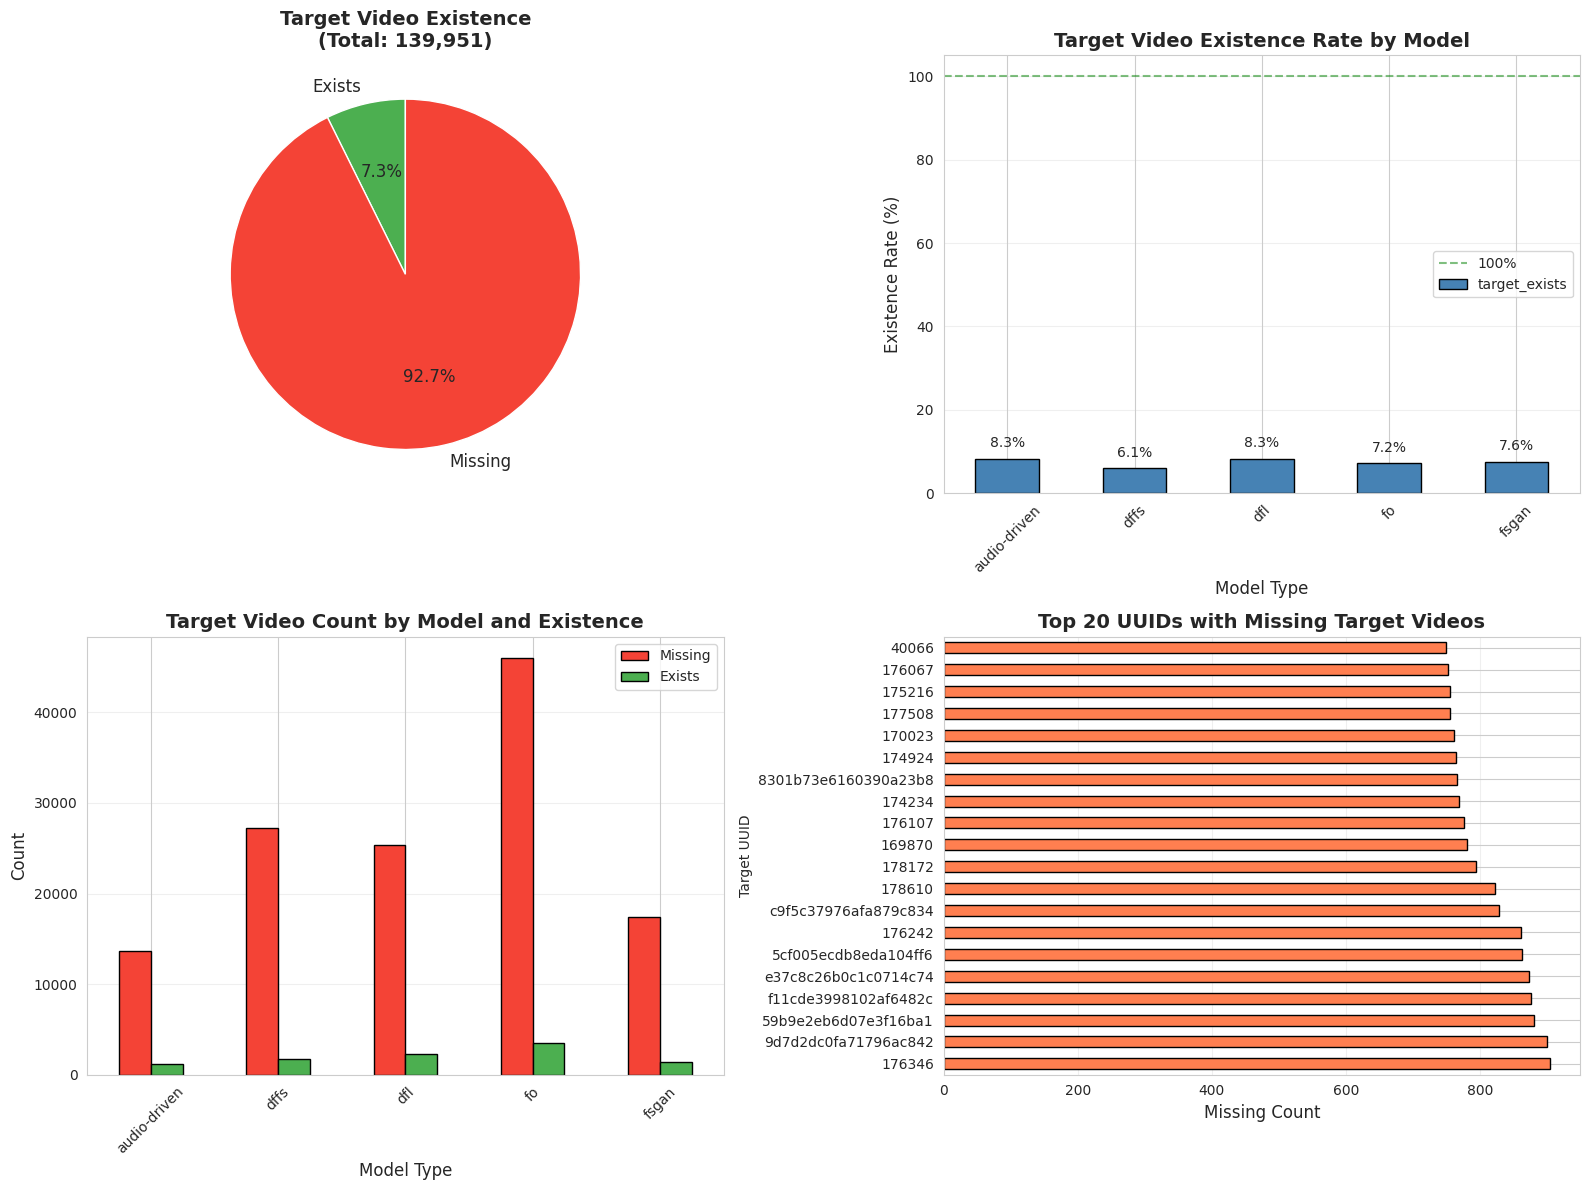

시각화 저장 완료: /home/elicer/liveness_detection/target_video_existence_analysis.png


In [20]:
# 시각화: 타겟영상 존재 여부
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 전체 존재 여부 파이 차트
existence_counts = df_metadata['target_exists'].value_counts()
labels = ['Exists', 'Missing']
colors = ['#4CAF50', '#F44336']
axes[0, 0].pie([exists_count, missing_count], labels=labels, autopct='%1.1f%%', 
               colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title(f'Target Video Existence\n(Total: {total_count:,})', 
                      fontsize=14, fontweight='bold')

# 2. 변조모델별 존재 비율
model_exists = df_metadata.groupby('변조모델')['target_exists'].mean() * 100
model_exists.plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Model Type', fontsize=12)
axes[0, 1].set_ylabel('Existence Rate (%)', fontsize=12)
axes[0, 1].set_title('Target Video Existence Rate by Model', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim([0, 105])
axes[0, 1].axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100%')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].legend()

# 값 표시
for i, v in enumerate(model_exists.values):
    axes[0, 1].text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

# 3. 변조모델별 개수 (존재/누락)
model_comparison = df_metadata.groupby(['변조모델', 'target_exists']).size().unstack(fill_value=0)
model_comparison.columns = ['Missing', 'Exists']
model_comparison.plot(kind='bar', ax=axes[1, 0], color=['#F44336', '#4CAF50'], 
                       edgecolor='black', stacked=False)
axes[1, 0].set_xlabel('Model Type', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title('Target Video Count by Model and Existence', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(['Missing', 'Exists'])
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 타겟UUID별 누락 비율 (상위 20개)
if missing_count > 0:
    uuid_missing = df_metadata[~df_metadata['target_exists']]['타겟UUID'].value_counts().head(20)
    uuid_missing.plot(kind='barh', ax=axes[1, 1], color='coral', edgecolor='black')
    axes[1, 1].set_xlabel('Missing Count', fontsize=12)
    axes[1, 1].set_ylabel('Target UUID', fontsize=10)
    axes[1, 1].set_title('Top 20 UUIDs with Missing Target Videos', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
else:
    axes[1, 1].text(0.5, 0.5, 'No Missing Videos', ha='center', va='center', 
                     fontsize=16, transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Missing Videos by UUID', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/elicer/liveness_detection/target_video_existence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("시각화 저장 완료: /home/elicer/liveness_detection/target_video_existence_analysis.png")

In [21]:
# 누락된 타겟영상 정보 저장
if missing_count > 0:
    missing_videos_df = df_metadata[~df_metadata['target_exists']].copy()
    missing_videos_df = missing_videos_df[['영상ID', '타겟영상', '타겟UUID', '소스UUID', '변조모델']]
    
    # CSV로 저장
    missing_csv_path = '/home/elicer/liveness_detection/missing_target_videos.csv'
    missing_videos_df.to_csv(missing_csv_path, index=False, encoding='utf-8')
    print(f"누락된 타겟영상 정보 저장: {missing_csv_path}")
    print(f"총 {len(missing_videos_df):,}개의 누락된 타겟영상")
    
    # 샘플 출력
    print("\n누락된 타겟영상 샘플 (처음 10개):")
    print(missing_videos_df.head(10))
    
    # 고유 타겟UUID 목록
    unique_missing_uuids = missing_videos_df['타겟UUID'].unique()
    print(f"\n누락된 고유 타겟UUID 수: {len(unique_missing_uuids)}개")
    
    # UUID 목록 저장
    uuid_list_path = '/home/elicer/liveness_detection/missing_target_uuids.txt'
    with open(uuid_list_path, 'w', encoding='utf-8') as f:
        for uuid in sorted(unique_missing_uuids):
            f.write(f"{uuid}\n")
    print(f"누락된 UUID 목록 저장: {uuid_list_path}")
else:
    print("모든 타겟영상이 존재합니다!")

누락된 타겟영상 정보 저장: /home/elicer/liveness_detection/missing_target_videos.csv
총 129,685개의 누락된 타겟영상

누락된 타겟영상 샘플 (처음 10개):
                       영상ID            타겟영상  타겟UUID  소스UUID 변조모델
0  174348_174348_4_0011.mp4  174348_001.mp4  174348  174348   fo
1  174348_174348_4_0012.mp4  174348_001.mp4  174348  174348   fo
2  174348_174348_4_0013.mp4  174348_001.mp4  174348  174348   fo
3  174348_174348_4_0014.mp4  174348_001.mp4  174348  174348   fo
4  174348_174348_4_0015.mp4  174348_001.mp4  174348  174348   fo
5  174348_174348_4_0016.mp4  174348_001.mp4  174348  174348   fo
6  174348_174348_4_0021.mp4  174348_002.mp4  174348  174348   fo
7  174348_174348_4_0022.mp4  174348_002.mp4  174348  174348   fo
8  174348_174348_4_0023.mp4  174348_002.mp4  174348  174348   fo
9  174348_174348_4_0024.mp4  174348_002.mp4  174348  174348   fo

누락된 고유 타겟UUID 수: 275개
누락된 UUID 목록 저장: /home/elicer/liveness_detection/missing_target_uuids.txt


In [22]:
# 전체 분석 결과 저장
analysis_csv_path = '/home/elicer/liveness_detection/deepfake_metadata_with_target_check.csv'
df_metadata.to_csv(analysis_csv_path, index=False, encoding='utf-8')
print(f"전체 분석 결과 저장: {analysis_csv_path}")

# 최종 리포트 생성
target_report = f"""
{'='*70}
           타겟영상 존재 여부 분석 리포트
{'='*70}

1. 전체 통계
   - 총 변조영상 수: {total_count:,}개
   - 타겟영상 존재: {exists_count:,}개 ({exists_count/total_count*100:.2f}%)
   - 타겟영상 누락: {missing_count:,}개 ({missing_count/total_count*100:.2f}%)

2. 변조모델별 통계
"""

for model in df_metadata['변조모델'].unique():
    model_df = df_metadata[df_metadata['변조모델'] == model]
    model_total = len(model_df)
    model_exists = model_df['target_exists'].sum()
    model_missing = model_total - model_exists
    target_report += f"""
   [{model}]
   - 총 개수: {model_total:,}개
   - 존재: {model_exists:,}개 ({model_exists/model_total*100:.2f}%)
   - 누락: {model_missing:,}개 ({model_missing/model_total*100:.2f}%)
"""

if exists_count > 0:
    target_report += f"""
3. 타겟영상이 발견된 폴더별 분포
"""
    folder_dist = df_metadata[df_metadata['target_exists']]['target_folder'].value_counts()
    for folder, count in folder_dist.items():
        target_report += f"   - {folder}: {count:,}개 ({count/exists_count*100:.2f}%)\n"

if missing_count > 0:
    target_report += f"""
4. 누락 분석
   - 누락된 고유 타겟UUID 수: {len(unique_missing_uuids):,}개
   - 누락된 타겟영상 목록: {missing_csv_path}
   - 누락된 UUID 목록: {uuid_list_path}
"""

target_report += f"""
5. 생성된 파일
   - 전체 분석 결과: {analysis_csv_path}
   - 시각화 이미지: /home/elicer/liveness_detection/target_video_existence_analysis.png
"""

if missing_count > 0:
    target_report += f"""   - 누락 영상 CSV: {missing_csv_path}
   - 누락 UUID 목록: {uuid_list_path}
"""

target_report += f"""
{'='*70}
"""

print(target_report)

# 리포트 파일로 저장
report_path = '/home/elicer/liveness_detection/target_video_check_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(target_report)

print(f"\n리포트 저장 완료: {report_path}")

전체 분석 결과 저장: /home/elicer/liveness_detection/deepfake_metadata_with_target_check.csv

           타겟영상 존재 여부 분석 리포트

1. 전체 통계
   - 총 변조영상 수: 139,951개
   - 타겟영상 존재: 10,266개 (7.34%)
   - 타겟영상 누락: 129,685개 (92.66%)

2. 변조모델별 통계

   [fo]
   - 총 개수: 49,586개
   - 존재: 3,546개 (7.15%)
   - 누락: 46,040개 (92.85%)

   [audio-driven]
   - 총 개수: 14,927개
   - 존재: 1,242개 (8.32%)
   - 누락: 13,685개 (91.68%)

   [dfl]
   - 총 개수: 27,680개
   - 존재: 2,299개 (8.31%)
   - 누락: 25,381개 (91.69%)

   [dffs]
   - 총 개수: 28,962개
   - 존재: 1,757개 (6.07%)
   - 누락: 27,205개 (93.93%)

   [fsgan]
   - 총 개수: 18,796개
   - 존재: 1,422개 (7.57%)
   - 누락: 17,374개 (92.43%)

3. 타겟영상이 발견된 폴더별 분포
   - 원본1: 10,266개 (100.00%)

4. 누락 분석
   - 누락된 고유 타겟UUID 수: 275개
   - 누락된 타겟영상 목록: /home/elicer/liveness_detection/missing_target_videos.csv
   - 누락된 UUID 목록: /home/elicer/liveness_detection/missing_target_uuids.txt

5. 생성된 파일
   - 전체 분석 결과: /home/elicer/liveness_detection/deepfake_metadata_with_target_check.csv
   - 시각화 이미지: /home/elicer/liveness

---

## 변조영상 Duration 합계와 원본영상 Duration 비교

변조영상들이 원본영상을 잘라서 만든 것인지 확인하기 위해, 같은 타겟영상을 사용한 변조영상들의 duration 합계가 원본영상 duration과 일치하는지 분석합니다.

In [23]:
# 타겟영상이 존재하는 변조영상만 필터링
df_with_target = df_metadata[df_metadata['target_exists']].copy()
print(f"타겟영상이 존재하는 변조영상: {len(df_with_target):,}개")

# 변조영상 경로 추출 (train_변조 폴더에서)
deepfake_base_path = '/home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조'
print(f"\n변조영상 기본 경로: {deepfake_base_path}")
print(f"경로 존재 여부: {os.path.exists(deepfake_base_path)}")

타겟영상이 존재하는 변조영상: 10,266개

변조영상 기본 경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조
경로 존재 여부: True


In [24]:
def find_deepfake_video_path(video_id, deepfake_base):
    """
    변조영상 ID로 실제 파일 경로 찾기
    """
    # 변조모델 폴더들을 순회
    for model_folder in os.listdir(deepfake_base):
        model_path = os.path.join(deepfake_base, model_folder)
        if os.path.isdir(model_path):
            # UUID 폴더들을 순회
            for uuid_folder in os.listdir(model_path):
                uuid_path = os.path.join(model_path, uuid_folder)
                if os.path.isdir(uuid_path):
                    # 영상 파일 찾기
                    video_path = os.path.join(uuid_path, video_id)
                    if os.path.exists(video_path):
                        return video_path
    return None

print("변조영상 경로 찾기 함수 정의 완료")

변조영상 경로 찾기 함수 정의 완료


In [25]:
# 샘플로 몇 개의 변조영상 duration 추출해보기
print("변조영상 경로 및 duration 확인 (샘플 5개):")
sample_count = 0
for idx, row in df_with_target.head(10).iterrows():
    video_id = row['영상ID']
    deepfake_path = find_deepfake_video_path(video_id, deepfake_base_path)
    if deepfake_path:
        duration = get_video_duration(deepfake_path)
        print(f"  {video_id}: {duration:.2f}초 (경로: {deepfake_path})")
        sample_count += 1
        if sample_count >= 5:
            break
    else:
        print(f"  {video_id}: 경로 찾기 실패")

변조영상 경로 및 duration 확인 (샘플 5개):
  13968_13968_4_0051.mp4: 15.02초 (경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조/fo1/13968/13968_13968_4_0051.mp4)
  13968_13968_4_0052.mp4: 15.02초 (경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조/fo1/13968/13968_13968_4_0052.mp4)
  13968_13968_4_0053.mp4: 15.02초 (경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조/fo1/13968/13968_13968_4_0053.mp4)
  13968_13968_4_0054.mp4: 15.02초 (경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조/fo1/13968/13968_13968_4_0054.mp4)
  13968_13968_4_0055.mp4: 15.02초 (경로: /home/elicer/liveness_detection/003.딥페이크/1.Training/원천데이터/train_변조/fo1/13968/13968_13968_4_0055.mp4)


In [26]:
# 모든 변조영상의 duration 추출
print(f"변조영상 duration 추출 중... (총 {len(df_with_target):,}개)")
print("이 작업은 시간이 걸릴 수 있습니다...\n")

deepfake_durations = []
deepfake_paths = []

for idx, row in tqdm(df_with_target.iterrows(), total=len(df_with_target), desc="Extracting deepfake durations"):
    video_id = row['영상ID']
    deepfake_path = find_deepfake_video_path(video_id, deepfake_base_path)
    
    if deepfake_path:
        duration = get_video_duration(deepfake_path)
        deepfake_durations.append(duration)
        deepfake_paths.append(deepfake_path)
    else:
        deepfake_durations.append(None)
        deepfake_paths.append(None)

# DataFrame에 추가
df_with_target['deepfake_duration'] = deepfake_durations
df_with_target['deepfake_path'] = deepfake_paths

# 유효한 데이터만 필터링
df_valid_comparison = df_with_target[df_with_target['deepfake_duration'].notna()].copy()
print(f"\nDuration 추출 완료: {len(df_valid_comparison):,}개 (전체의 {len(df_valid_comparison)/len(df_with_target)*100:.2f}%)")

변조영상 duration 추출 중... (총 10,266개)
이 작업은 시간이 걸릴 수 있습니다...



Extracting deepfake durations:  92%|█████████▏| 9399/10266 [07:09<00:40, 21.65it/s][mov,mp4,m4a,3gp,3g2,mj2 @ 0x55c757b814c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x55c757b814c0] moov atom not found
Extracting deepfake durations: 100%|██████████| 10266/10266 [07:49<00:00, 21.86it/s]


Duration 추출 완료: 10,249개 (전체의 99.83%)


In [27]:
# 타겟영상의 duration 추출
print("타겟영상(원본) duration 추출 중...")

target_durations = []
for idx, row in tqdm(df_valid_comparison.iterrows(), total=len(df_valid_comparison), desc="Extracting target durations"):
    target_path = row['target_path']
    if target_path and os.path.exists(target_path):
        duration = get_video_duration(target_path)
        target_durations.append(duration)
    else:
        target_durations.append(None)

df_valid_comparison['target_duration'] = target_durations

# 타겟 duration도 유효한 것만 필터링
df_final = df_valid_comparison[df_valid_comparison['target_duration'].notna()].copy()
print(f"\n최종 비교 가능한 데이터: {len(df_final):,}개")

타겟영상(원본) duration 추출 중...


Extracting target durations: 100%|██████████| 10249/10249 [02:41<00:00, 63.60it/s]


최종 비교 가능한 데이터: 10,249개


In [17]:
# 타겟영상별로 그룹화하여 변조영상 duration 합계 계산
print("=" * 70)
print("타겟영상별 변조영상 Duration 합계 분석")
print("=" * 70)

# 타겟영상별로 그룹화
grouped = df_final.groupby('타겟영상').agg({
    'deepfake_duration': ['sum', 'count', 'mean'],
    'target_duration': 'first',  # 같은 타겟영상은 같은 duration
    '타겟UUID': 'first'
}).reset_index()

# 컬럼명 정리
grouped.columns = ['타겟영상', 'deepfake_sum', 'deepfake_count', 'deepfake_mean', 'target_duration', '타겟UUID']

# 차이 계산
grouped['duration_diff'] = grouped['deepfake_sum'] - grouped['target_duration']
grouped['duration_diff_abs'] = grouped['duration_diff'].abs()
grouped['match_ratio'] = (grouped['deepfake_sum'] / grouped['target_duration']) * 100

print(f"\n총 {len(grouped)}개의 고유 타겟영상 분석")
print(f"\n샘플 데이터 (처음 10개):")
print(grouped.head(10))

SyntaxError: unterminated string literal (detected at line 22) (2299729484.py, line 22)

In [16]:
# 매칭 분석
print("\n" + "=" * 70)
print("Duration 매칭 분석")
print("=" * 70)

# 허용 오차 설정 (예: 1초 이내 차이는 매칭으로 간주)
tolerance = 1.0  # 초

matched = grouped[grouped['duration_diff_abs'] <= tolerance]
not_matched = grouped[grouped['duration_diff_abs'] > tolerance]

print(f"\n허용 오차: ±{tolerance}초")
print(f"매칭된 타겟영상: {len(matched)}개 ({len(matched)/len(grouped)*100:.2f}%)")
print(f"불일치 타겟영상: {len(not_matched)}개 ({len(not_matched)/len(grouped)*100:.2f}%)")

print(f"\n=== Duration 차이 통계 ===")
print(f"평균 차이: {grouped['duration_diff'].mean():.2f}초")
print(f"중앙값 차이: {grouped['duration_diff'].median():.2f}초")
print(f"표준편차: {grouped['duration_diff'].std():.2f}초")
print(f"최소 차이: {grouped['duration_diff'].min():.2f}초")
print(f"최대 차이: {grouped['duration_diff'].max():.2f}초")

print(f"\n=== 매칭 비율 통계 ===")
print(f"평균 매칭 비율: {grouped['match_ratio'].mean():.2f}%")
print(f"중앙값 매칭 비율: {grouped['match_ratio'].median():.2f}%")
print(f"100% 매칭: {len(grouped[grouped['match_ratio'] == 100])}개")


Duration 매칭 분석


NameError: name 'grouped' is not defined

In [15]:
# 시각화: Duration 비교 분석
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. 변조영상 합계 vs 원본 duration 산점도
axes[0, 0].scatter(grouped['target_duration'], grouped['deepfake_sum'], alpha=0.6, s=50)
axes[0, 0].plot([0, grouped['target_duration'].max()], [0, grouped['target_duration'].max()], 
                'r--', label='Perfect Match', linewidth=2)
axes[0, 0].set_xlabel('Target Duration (seconds)', fontsize=12)
axes[0, 0].set_ylabel('Deepfake Sum Duration (seconds)', fontsize=12)
axes[0, 0].set_title('Target Duration vs Deepfake Sum Duration', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Duration 차이 분포
axes[0, 1].hist(grouped['duration_diff'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', label='Zero Difference', linewidth=2)
axes[0, 1].set_xlabel('Duration Difference (seconds)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Duration Differences', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 매칭 비율 분포
axes[0, 2].hist(grouped['match_ratio'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(100, color='green', linestyle='--', label='100% Match', linewidth=2)
axes[0, 2].set_xlabel('Match Ratio (%)', fontsize=12)
axes[0, 2].set_ylabel('Frequency', fontsize=12)
axes[0, 2].set_title('Distribution of Match Ratios', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. 매칭 여부 파이 차트
match_counts = [len(matched), len(not_matched)]
match_labels = [f'Matched (±{tolerance}s)', f'Not Matched']
colors = ['#4CAF50', '#FF9800']
axes[1, 0].pie(match_counts, labels=match_labels, autopct='%1.1f%%', colors=colors, 
               startangle=90, textprops={'fontsize': 12})
axes[1, 0].set_title(f'Match Status\n(Tolerance: ±{tolerance}s)', fontsize=14, fontweight='bold')

# 5. 변조영상 개수별 분포
axes[1, 1].hist(grouped['deepfake_count'], bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Deepfake Videos per Target', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Distribution of Deepfake Video Counts', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 6. Duration 차이 절대값 상위 20개
top_diff = grouped.nlargest(20, 'duration_diff_abs')
axes[1, 2].barh(range(len(top_diff)), top_diff['duration_diff_abs'], color='indianred', edgecolor='black')
axes[1, 2].set_yticks(range(len(top_diff)))
axes[1, 2].set_yticklabels([f"{vid[:15]}..." if len(vid) > 15 else vid for vid in top_diff['타겟영상']], fontsize=9)
axes[1, 2].set_xlabel('Absolute Duration Difference (seconds)', fontsize=12)
axes[1, 2].set_title('Top 20 Videos with Largest Duration Differences', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/home/elicer/liveness_detection/duration_comparison_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("시각화 저장 완료: /home/elicer/liveness_detection/duration_comparison_analysis.png")

SyntaxError: unexpected character after line continuation character (3810109703.py, line 51)

In [14]:
# 불일치 영상 목록 저장
if len(not_matched) > 0:
    not_matched_sorted = not_matched.sort_values('duration_diff_abs', ascending=False)
    
    mismatch_csv_path = '/home/elicer/liveness_detection/duration_mismatch_videos.csv'
    not_matched_sorted.to_csv(mismatch_csv_path, index=False, encoding='utf-8')
    print(f"불일치 영상 목록 저장: {mismatch_csv_path}")
    print(f"총 {len(not_matched_sorted)}개의 불일치 영상")
    
    print("\n불일치 영상 샘플 (상위 10개):")
    print(not_matched_sorted[['타겟영상', 'target_duration', 'deepfake_sum', 'duration_diff', 'match_ratio']].head(10))

# 전체 결과 저장
comparison_csv_path = '/home/elicer/liveness_detection/duration_comparison_results.csv'
grouped.to_csv(comparison_csv_path, index=False, encoding='utf-8')
print(f"\n전체 비교 결과 저장: {comparison_csv_path}")

NameError: name 'not_matched' is not defined

In [1]:
# 최종 종합 리포트 생성
comparison_report = f"""
{'='*80}
            변조영상 Duration 합계 vs 원본영상 Duration 비교 리포트
{'='*80}

1. 분석 개요
   - 분석 대상 타겟영상 수: {len(grouped):,}개
   - 총 변조영상 수: {len(df_final):,}개
   - 타겟영상당 평균 변조영상 수: {grouped['deepfake_count'].mean():.2f}개

2. Duration 매칭 결과 (허용 오차: ±{tolerance}초)
   - 매칭된 타겟영상: {len(matched):,}개 ({len(matched)/len(grouped)*100:.2f}%)
   - 불일치 타겟영상: {len(not_matched):,}개 ({len(not_matched)/len(grouped)*100:.2f}%)

3. Duration 차이 통계
   - 평균 차이: {grouped['duration_diff'].mean():.2f}초
   - 중앙값 차이: {grouped['duration_diff'].median():.2f}초
   - 표준편차: {grouped['duration_diff'].std():.2f}초
   - 최소 차이: {grouped['duration_diff'].min():.2f}초
   - 최대 차이: {grouped['duration_diff'].max():.2f}초
   - 절대값 평균: {grouped['duration_diff_abs'].mean():.2f}초

4. 매칭 비율 통계
   - 평균 매칭 비율: {grouped['match_ratio'].mean():.2f}%
   - 중앙값 매칭 비율: {grouped['match_ratio'].median():.2f}%
   - 100% 정확히 매칭: {len(grouped[grouped['match_ratio'] == 100]):,}개
   - 95% 이상 매칭: {len(grouped[grouped['match_ratio'] >= 95]):,}개
   - 90% 이상 매칭: {len(grouped[grouped['match_ratio'] >= 90]):,}개

5. 원본 vs 변조영상 합계 비교
   - 원본 평균 duration: {grouped['target_duration'].mean():.2f}초
   - 변조영상 합계 평균: {grouped['deepfake_sum'].mean():.2f}초
   - 변조영상 개별 평균: {grouped['deepfake_mean'].mean():.2f}초

6. 분석 결과 해석
"""

# 매칭 비율에 따른 해석
if len(matched) / len(grouped) > 0.9:
    comparison_report += """
   ✓ 90% 이상의 타겟영상에서 변조영상 합계가 원본 duration과 매칭됩니다.
   ✓ 이는 변조영상들이 원본영상을 잘라서 만들어졌음을 강하게 시사합니다.
"""
elif len(matched) / len(grouped) > 0.7:
    comparison_report += """
   ○ 70% 이상의 타겟영상에서 변조영상 합계가 원본 duration과 매칭됩니다.
   ○ 대부분의 변조영상이 원본영상을 잘라서 만들어진 것으로 보입니다.
"""
else:
    comparison_report += """
   × 매칭 비율이 70% 미만입니다.
   × 변조영상들이 원본영상을 단순히 잘라서 만든 것이 아닐 수 있습니다.
   × 추가 전처리(크롭, 리샘플링 등)가 있었을 가능성이 있습니다.
"""

comparison_report += f"""

7. 생성된 파일
   - 전체 비교 결과: {comparison_csv_path}
   - 시각화 이미지: /home/elicer/liveness_detection/duration_comparison_analysis.png
"""

if len(not_matched) > 0:
    comparison_report += f"""   - 불일치 영상 목록: {mismatch_csv_path}
"""

comparison_report += f"""
{'='*80}
"""

print(comparison_report)

# 리포트 저장
comparison_report_path = '/home/elicer/liveness_detection/duration_comparison_report.txt'
with open(comparison_report_path, 'w', encoding='utf-8') as f:
    f.write(comparison_report)

print(f"\n리포트 저장 완료: {comparison_report_path}")

NameError: name 'grouped' is not defined